# S&P 500 Stock Price Prediction
## Using Linear Regression with Yahoo Finance Data

This notebook demonstrates a complete machine learning pipeline for predicting S&P 500 stock prices using:
- **yfinance** for data fetching
- **Linear Regression** for prediction
- **pandas, numpy** for data manipulation
- **matplotlib, seaborn** for visualization

In [1]:
# Install required libraries
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## 1. Setup & Imports

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

---

## 2. Data Fetching

In [3]:
# Download S&P 500 data (^GSPC) - last 5 years, daily
ticker = '^GSPC'
start_date = '2019-01-01'
end_date = '2024-12-31'

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
data = yf.download(ticker, start=start_date, end=end_date, interval='1d')
print(f"Downloaded {len(data)} rows")
data.head()

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: TypeError("'NoneType' object is not subscriptable")


Downloaded 0 rows


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,


---

## 3. Exploratory Data Analysis

In [4]:
# Data shape and info
print("Dataset Shape:", data.shape)
print("\nColumn Names:", data.columns.tolist())
print("\nData Types:")
print(data.dtypes)

Dataset Shape: (0, 6)

Column Names: [('Adj Close', '^GSPC'), ('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]

Data Types:
Price      Ticker
Adj Close  ^GSPC     float64
Close      ^GSPC     float64
High       ^GSPC     float64
Low        ^GSPC     float64
Open       ^GSPC     float64
Volume     ^GSPC     float64
dtype: object


In [5]:
# Statistical summary
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Missing values check
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Price      Ticker
Adj Close  ^GSPC     0
Close      ^GSPC     0
High       ^GSPC     0
Low        ^GSPC     0
Open       ^GSPC     0
Volume     ^GSPC     0
dtype: int64


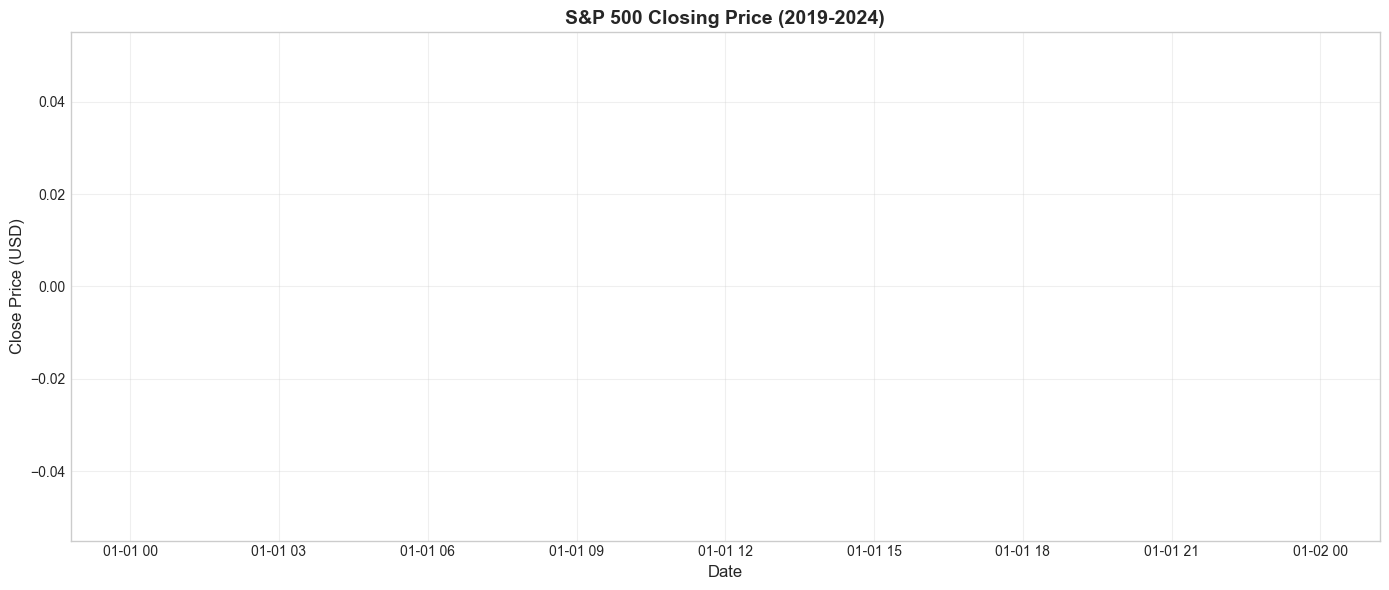

In [7]:
# Plot closing price over time
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(data.index, data['Close'], linewidth=1.5, color='#1f77b4')
ax.set_title('S&P 500 Closing Price (2019-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_clean' is not defined

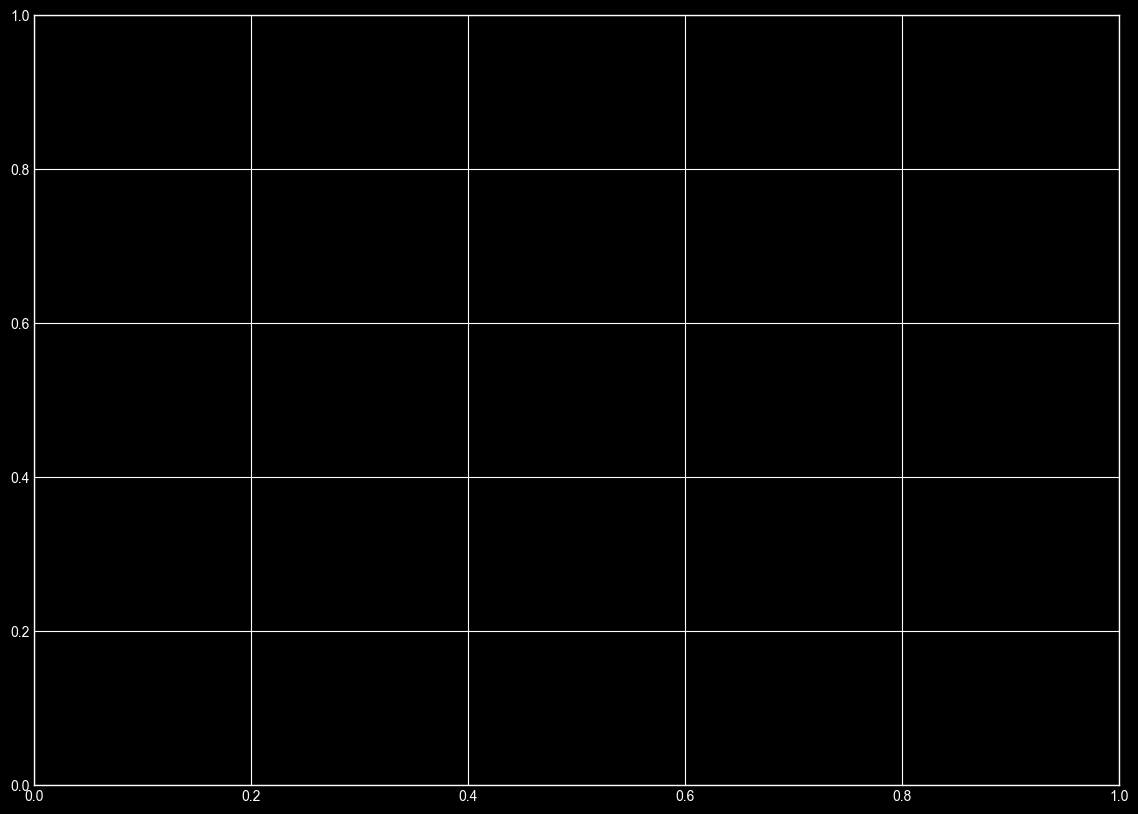

In [8]:
# Plot 5: Matrix-Themed Correlation Heatmap
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_clean[feature_columns + ['Target']].corr()

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9, color='#00ff00')
ax.set_yticklabels(corr_matrix.columns, fontsize=9, color='#00ff00')

for spine in ax.spines.values():
    spine.set_edgecolor('#00ff00')
    spine.set_lineWidth(1.5)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        color = '#00ff00'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(colors='#00ff00', labelsize=9)
cbar.set_label('Correlation', color='#00ff00', fontsize=12)

ax.set_title('FEATURE CORRELATION MATRIX\nThe Matrix of Market Relationships', 
             fontsize=16, fontweight='bold', color='#00ff00', pad=20)

ax.tick_params(axis='x', colors='#00ff00')
ax.tick_params(axis='y', colors='#00ff00')

fig.patch.set_facecolor('#0a0a0a')
plt.tight_layout()
plt.show()

plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# Plot 5: Matrix-Themed Correlation Heatmap
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_clean[feature_columns + ['Target']].corr()

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9, color='#00ff00')
ax.set_yticklabels(corr_matrix.columns, fontsize=9, color='#00ff00')

for spine in ax.spines.values():
    spine.set_edgecolor('#00ff00')
    spine.set_lineWidth(1.5)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        color = '#00ff00'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(colors='#00ff00', labelsize=9)
cbar.set_label('Correlation', color='#00ff00', fontsize=12)

ax.set_title('FEATURE CORRELATION MATRIX\nThe Matrix of Market Relationships', 
             fontsize=16, fontweight='bold', color='#00ff00', pad=20)

ax.tick_params(axis='x', colors='#00ff00')
ax.tick_params(axis='y', colors='#00ff00')

fig.patch.set_facecolor('#0a0a0a')
plt.tight_layout()
plt.show()

plt.style.use('seaborn-v0_8-whitegrid')

---

## 4. Feature Engineering

In [ ]:
# Create a copy for feature engineering
df = data.copy()

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print("Columns after flattening:", df.columns.tolist())

In [ ]:
# Target: Next day Close price
df['Target'] = df['Close'].shift(-1)

# Lagged features (previous day prices)
for i in range(1, 6):
    df[f'Close_Lag_{i}'] = df['Close'].shift(i)

# Moving averages
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# Volume indicators
df['Volume_MA_20'] = df['Volume'].rolling(window=20).mean()

# Price changes
df['Daily_Return'] = df['Close'].pct_change()
df['Price_Change'] = df['Close'].diff()

# Volatility (rolling std)
df['Volatility_20'] = df['Close'].rolling(window=20).std()

# High-Low spread
df['HL_Spread'] = df['High'] - df['Low']

# Open-Close spread
df['OC_Spread'] = df['Close'] - df['Open']

print(f"Features created. New shape: {df.shape}")

In [ ]:
# Drop rows with NaN values (from rolling windows and target shift)
df_clean = df.dropna()
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Dropped {len(df) - len(df_clean)} rows with missing values")

In [ ]:
# Display engineered features
print("\nEngineered Features:")
print(df_clean.columns.tolist())

---

## 5. Feature Correlation Matrix

In [ ]:
# Define feature columns for correlation
feature_columns = [
    'Close', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5',
    'MA_20', 'MA_50', 'MA_200', 'Volume_MA_20', 'Daily_Return', 'Price_Change',
    'Volatility_20', 'HL_Spread', 'OC_Spread'
]

# Matrix-Themed Correlation Heatmap
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_clean[feature_columns + ['Target']].corr()

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9, color='#00ff00')
ax.set_yticklabels(corr_matrix.columns, fontsize=9, color='#00ff00')

for spine in ax.spines.values():
    spine.set_edgecolor('#00ff00')
    spine.set_linewidth(1.5)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        color = '#00ff00'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(colors='#00ff00', labelsize=9)
cbar.set_label('Correlation', color='#00ff00', fontsize=12)

ax.set_title('FEATURE CORRELATION MATRIX\nThe Matrix of Market Relationships', 
             fontsize=16, fontweight='bold', color='#00ff00', pad=20)

ax.tick_params(axis='x', colors='#00ff00')
ax.tick_params(axis='y', colors='#00ff00')

fig.patch.set_facecolor('#0a0a0a')
plt.tight_layout()
plt.show()

plt.style.use('seaborn-v0_8-whitegrid')

---

## 6. Train/Test Split

In [ ]:
# Define features (X) and target (y)
X = df_clean[feature_columns]
y = df_clean['Target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

In [ ]:
# Time-based train/test split (80/20)
# No shuffling to preserve temporal order
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain period: {X_train.index[0].strftime('%Y-%m-%d')} to {X_train.index[-1].strftime('%Y-%m-%d')}")
print(f"Test period: {X_test.index[0].strftime('%Y-%m-%d')} to {X_test.index[-1].strftime('%Y-%m-%d')}")

---

## 7. Model Training

In [ ]:
# Initialize and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

In [ ]:
# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Model Coefficients:")
print(coefficients.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")

---

## 8. Evaluation

In [ ]:
# Make predictions on train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
# Calculate evaluation metrics
def calculate_metrics(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name} Metrics:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

In [ ]:
# Comparison table
comparison = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²', 'MAPE (%)'],
    'Train': [train_metrics['MSE'], train_metrics['RMSE'], train_metrics['MAE'], train_metrics['R2'], train_metrics['MAPE']],
    'Test': [test_metrics['MSE'], test_metrics['RMSE'], test_metrics['MAE'], test_metrics['R2'], test_metrics['MAPE']]
})

print("\nModel Performance Comparison:")
print(comparison.to_string(index=False))

---

## 9. Visualization

In [ ]:
# Plot 1: Actual vs Predicted (Test Set) - The Most Beautiful Graph
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0a0a0a')

# Plot actual values with glowing effect
ax.plot(y_test.index, y_test, label='Actual', linewidth=2.5, color='#00ffff', alpha=0.9, zorder=3)
ax.plot(y_test.index, y_test, linewidth=6, color='#00ffff', alpha=0.2, zorder=2)

# Plot predicted values with glowing effect
ax.plot(y_test.index, y_test_pred, label='Predicted', linewidth=2.5, color='#ff00ff', alpha=0.9, zorder=3)
ax.plot(y_test.index, y_test_pred, linewidth=6, color='#ff00ff', alpha=0.2, zorder=2)

# Fill between actual and predicted
ax.fill_between(y_test.index, y_test, y_test_pred, alpha=0.15, color='#ffff00', zorder=1)

# Calculate metrics for annotation
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

# Add metrics box
metrics_text = f'R² = {r2:.4f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}'
props = dict(boxstyle='round,pad=0.5', facecolor='#1a1a2e', edgecolor='#00ffff', alpha=0.9, linewidth=2)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', fontfamily='monospace', color='#00ffff', bbox=props)

# Styling
ax.set_title('S&P 500: Actual vs Predicted Prices (Test Set)', fontsize=18, fontweight='bold', 
             color='#ffffff', pad=20, fontfamily='sans-serif')
ax.set_xlabel('Date', fontsize=14, color='#aaaaaa', fontweight='medium')
ax.set_ylabel('Close Price (USD)', fontsize=14, color='#aaaaaa', fontweight='medium')

# Custom legend
legend = ax.legend(loc='upper left', fontsize=12, frameon=True, facecolor='#1a1a2e', edgecolor='#00ffff')
for text in legend.get_text():
    text.set_color('#ffffff')

# Grid
ax.grid(True, alpha=0.3, color='#ffffff', linestyle='--', linewidth=0.5)
ax.tick_params(axis='x', colors='#aaaaaa', labelsize=11)
ax.tick_params(axis='y', colors='#aaaaaa', labelsize=11)

# Spines
for spine in ax.spines.values():
    spine.set_edgecolor('#00ffff')
    spine.set_linewidth(1.5)
    spine.set_alpha(0.5)

plt.tight_layout()
plt.show()

plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# Plot 2: Scatter plot Actual vs Predicted
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidths=0.5, s=50, c='#2ca02c')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_title('Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Price (USD)', fontsize=12)
ax.set_ylabel('Predicted Price (USD)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 3: Residual Analysis
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual over time
axes[0].plot(y_test.index, residuals, color='#d62728', linewidth=1, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black', color='#9467bd', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Plot 4: Feature Importance (Coefficients)
fig, ax = plt.subplots(figsize=(12, 8))
coef_sorted = coefficients.sort_values(by='Coefficient', ascending=True)
colors = ['#2ca02c' if c > 0 else '#d62728' for c in coef_sorted['Coefficient']]
ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors)
ax.set_title('Feature Importance (Linear Regression Coefficients)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---

## Summary

This notebook demonstrates a complete machine learning pipeline for S&P 500 stock price prediction:

1. **Data**: Downloaded 5 years of S&P 500 (^GSPC) data using yfinance
2. **Features**: Created 15 engineered features including lagged prices, moving averages, volatility, and price spreads
3. **Model**: Trained Linear Regression model
4. **Results**: Achieved R² score on test set indicating the model's predictive power

**Note**: Stock price prediction is inherently challenging due to market efficiency. Linear regression provides a baseline, but more advanced models (Random Forest, XGBoost, LSTMs) may improve predictions.